# HỒI QUY LOGISTIC VỚI HÀM MẤT MÁT BINARY CROSS-ENTROPY (BCE)
## BÀI TOÁN PHÂN LOẠI ĐỘ CHÍN TRÁI CÂY (0, 1) TRÊN DATASET 1000 QUẢ
### THUẬT TOÁN TỐI ƯU HÓA: STOCHASTIC GRADIENT DESCENT (SGD)

---
### 👥 THÔNG TIN NHÓM THỰC HIỆN

| STT | Họ và Tên | Mã số sinh viên | Vai trò & Nhiệm vụ thực hiện | Tỷ lệ đóng góp (%) |
|:---:|:---|:---:|:---|:---:|
| 1 | [Họ tên sinh viên 1] | [MSSV 1] | Trưởng nhóm: Thuật toán SGD, lý thuyết toán học BCE | 34% |
| 2 | [Họ tên sinh viên 2] | [MSSV 2] | Xây dựng dataset 1000 mẫu, chuẩn hóa Z-score, code hàm BCE & Gradient | 33% |
| 3 | [Họ tên sinh viên 3] | [MSSV 3] | Huấn luyện mô hình, vẽ biểu đồ ranh giới phân lớp & đánh giá độ chính xác | 33% |


---
# PHẦN 1: BÀI TOÁN VÀ CƠ SỞ TOÁN HỌC CỦA BINARY CROSS-ENTROPY

## 1.1. Mô tả bài toán
* **Bài toán:** Phân loại nhị phân (*Binary Classification*) độ chín của quả.
  * **Lớp 0 (Unripe):** Quả chưa chín / quả xanh. Nhãn $y = 0$.
  * **Lớp 1 (Ripe):** Quả đã chín. Nhãn $y = 1$.
* **Dữ liệu (Datapoints):** **1000 quả** (500 quả chín và 500 quả chưa chín).
* **Đặc trưng (Features):**
  * $x_1$: Khối lượng quả (Weight - grams).
  * $x_2$: Mã màu sắc vỏ quả (Color Code - từ 0.0 đến 2.0).

---
## 1.2. Hàm Sigmoid và Xác suất dự đoán
Tổ hợp tuyến tính của các đặc trưng:
$$z = \mathbf{w}^T \mathbf{x} + b = w_1 x_1 + w_2 x_2 + b$$

Hàm kích hoạt Sigmoid chuyển đổi giá trị $z$ về khoảng xác suất $(0, 1)$:
$$p = \sigma(z) = \frac{1}{1 + e^{-z}}$$

Trong đó, $p$ đại diện cho xác suất quả thuộc về lớp chín:
* $P(y = 1 | \mathbf{x}) = p$
* $P(y = 0 | \mathbf{x}) = 1 - p$

Đạo hàm của hàm Sigmoid có tính chất:
$$\sigma'(z) = \frac{\partial p}{\partial z} = p(1 - p)$$

---
## 1.3. Hàm mất mát Binary Cross-Entropy (BCE) và Đạo hàm Gradient
Hàm mất mát BCE cho 1 mẫu dữ liệu $(\mathbf{x}_i, y_i)$:
$$\mathcal{L}(y_i, p_i) = - \left[ y_i \ln(p_i) + (1 - y_i) \ln(1 - p_i) \right]$$

### Chứng minh đạo hàm từng bước (Chain Rule):
1. **Đạo hàm của Loss theo xác suất $p_i$:**
   $$\frac{\partial \mathcal{L}}{\partial p_i} = -\frac{y_i}{p_i} - \frac{1 - y_i}{1 - p_i} \cdot (-1) = -\frac{y_i}{p_i} + \frac{1 - y_i}{1 - p_i} = \frac{p_i - y_i}{p_i(1 - p_i)}$$

2. **Đạo hàm của xác suất $p_i$ theo $z_i$:**
   $$\frac{\partial p_i}{\partial z_i} = p_i(1 - p_i)$$

3. **Nhân theo quy tắc chuỗi để tính đạo hàm theo $z_i$:**
   $$\frac{\partial \mathcal{L}}{\partial z_i} = \frac{\partial \mathcal{L}}{\partial p_i} \cdot \frac{\partial p_i}{\partial z_i} = \frac{p_i - y_i}{p_i(1 - p_i)} \cdot p_i(1 - p_i) = p_i - y_i$$
   *(Mẫu số $p_i(1 - p_i)$ triệt tiêu hoàn toàn với đạo hàm Sigmoid!)*

4. **Đạo hàm Gradient theo trọng số $\mathbf{w}$ và bias $b$:**
   $$\nabla_{\mathbf{w}} \mathcal{L} = (p_i - y_i) \mathbf{x}_i$$
   $$\nabla_{b} \mathcal{L} = p_i - y_i$$

### Tại sao BCE là hàm mất mát chuẩn mực cho Logistic Regression?
* **Hàm lồi toàn cục (Convex Function):** Đảm bảo thuật toán SGD luôn hội tụ về điểm tối ưu toàn cục duy nhất, không bị kẹt ở các cực tiểu địa phương (*Local minima*).
* **Không bị triệt tiêu Gradient (*No Vanishing Gradient*):** Vì đạo hàm tỷ lệ trực tiếp với sai số $(p_i - y_i)$, khi mô hình dự đoán sai nhiều thì lực kéo gradient càng lớn, giúp mô hình học rất nhanh.


In [1]:
# Import các thư viện cơ bản
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Cấu hình giao diện biểu đồ
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline

# Cố định seed ngẫu nhiên để kết quả có thể tái lập 100%
np.random.seed(42)
print("Đã nạp thành công các thư viện cần thiết!")


Đã nạp thành công các thư viện cần thiết!


---
# PHẦN 2: TẠO TẬP DỮ LIỆU 1000 QUẢ VÀ TIỀN XỬ LÝ (CHUẨN HÓA Z-SCORE)


In [2]:
# Tạo bộ dữ liệu 1000 quả phân loại theo 2 đặc trưng
n_samples_each = 500

# 500 quả chưa chín (Class 0): Cân nặng ~155g, màu xanh lục (0.0 - 0.7)
weights_unripe = np.random.normal(loc=155, scale=28, size=n_samples_each)
colors_unripe = np.random.normal(loc=0.45, scale=0.35, size=n_samples_each)
colors_unripe = np.clip(colors_unripe, 0.0, 2.0)
y_unripe = np.zeros(n_samples_each)

# 500 quả đã chín (Class 1): Cân nặng ~205g, màu vàng cam chín (1.2 - 2.0)
weights_ripe = np.random.normal(loc=205, scale=28, size=n_samples_each)
colors_ripe = np.random.normal(loc=1.55, scale=0.35, size=n_samples_each)
colors_ripe = np.clip(colors_ripe, 0.0, 2.0)
y_ripe = np.ones(n_samples_each)

# Ghép thành ma trận X_raw và vector nhãn y
X_raw = np.vstack([
    np.column_stack([weights_unripe, colors_unripe]),
    np.column_stack([weights_ripe, colors_ripe])
])
y = np.concatenate([y_unripe, y_ripe]).astype(int)

# Đưa vào DataFrame
df = pd.DataFrame({
    'Weight_g': X_raw[:, 0],
    'Color_Code': X_raw[:, 1],
    'Label': y,
    'Class_Name': np.where(y == 1, 'Chín (Ripe - Class 1)', 'Chưa chín (Unripe - Class 0)')
})

print(f"Tổng số mẫu trong dataset: {len(df)} quả")
print(f"Số lượng quả chưa chín (0): {np.sum(y == 0)} quả")
print(f"Số lượng quả đã chín   (1): {np.sum(y == 1)} quả")
print("\n10 mẫu đầu tiên của dataset:")
print(df.head(10))


Tổng số mẫu trong dataset: 1000 quả
Số lượng quả chưa chín (0): 500 quả
Số lượng quả đã chín   (1): 500 quả

10 mẫu đầu tiên của dataset:
     Weight_g  Color_Code  Label                    Class_Name
0  168.907996    0.774162      0  Chưa chín (Unripe - Class 0)
1  151.128600    1.118296      0  Chưa chín (Unripe - Class 0)
2  173.135279    0.000000      0  Chưa chín (Unripe - Class 0)
3  197.644836    0.647039      0  Chưa chín (Unripe - Class 0)
4  148.443706    0.222275      0  Chưa chín (Unripe - Class 0)
5  148.444165    0.279506      0  Chưa chín (Unripe - Class 0)
6  199.217959    0.242662      0  Chưa chín (Unripe - Class 0)
7  176.488172    0.147603      0  Chưa chín (Unripe - Class 0)
8  141.854717    0.466983      0  Chưa chín (Unripe - Class 0)
9  170.191681    0.159167      0  Chưa chín (Unripe - Class 0)


In [3]:
# Chuẩn hóa dữ liệu bằng phương pháp Z-score: (X - mean) / std
X_mean = np.mean(X_raw, axis=0)
X_std = np.std(X_raw, axis=0)

X_norm = (X_raw - X_mean) / X_std

print("Giá trị trung bình đặc trưng (Mean):", X_mean.round(2))
print("Độ lệch chuẩn đặc trưng (Std)      :", X_std.round(2))
print("\n5 mẫu dữ liệu sau khi chuẩn hóa Z-score:\n", X_norm[:5].round(4))


Giá trị trung bình đặc trưng (Mean): [181.61   1.01]
Độ lệch chuẩn đặc trưng (Std)      : [38.39  0.62]

5 mẫu dữ liệu sau khi chuẩn hóa Z-score:
 [[-0.3309 -0.3794]
 [-0.794   0.1736]
 [-0.2208 -1.6236]
 [ 0.4175 -0.5837]
 [-0.8639 -1.2664]]


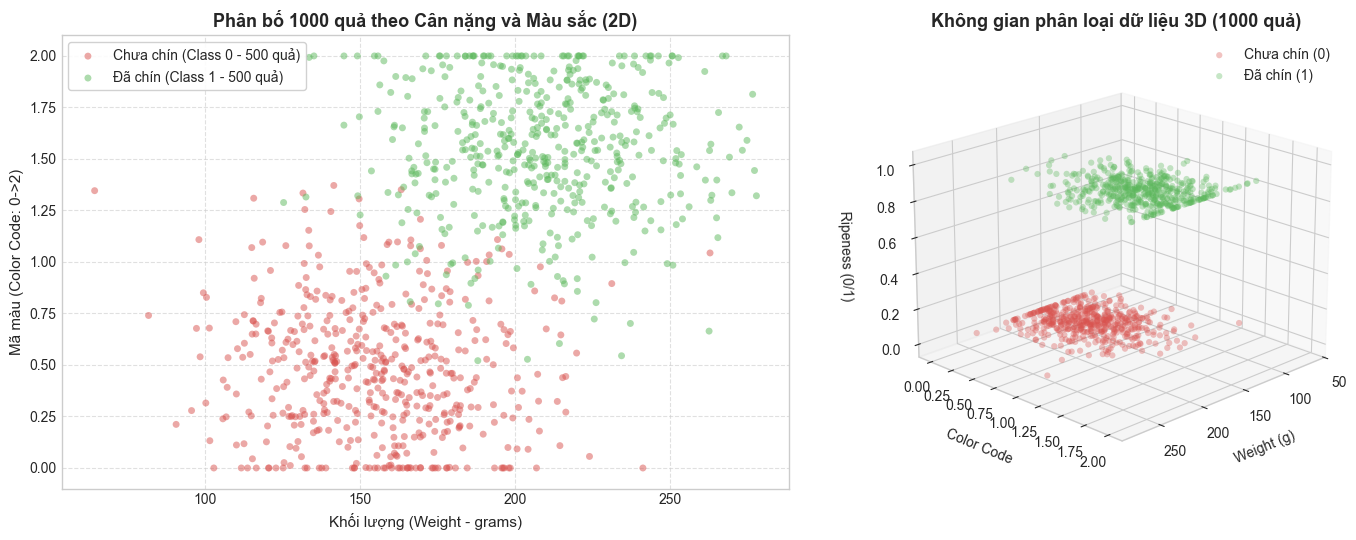

In [4]:
# Trực quan hóa dữ liệu 1000 quả trên không gian 2D và 3D
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Biểu đồ 2D
ax1 = axes[0]
ax1.scatter(df[df['Label'] == 0]['Weight_g'], df[df['Label'] == 0]['Color_Code'],
            c='#d9534f', label='Chưa chín (Class 0 - 500 quả)', alpha=0.5, s=25, edgecolors='none')
ax1.scatter(df[df['Label'] == 1]['Weight_g'], df[df['Label'] == 1]['Color_Code'],
            c='#5cb85c', label='Đã chín (Class 1 - 500 quả)', alpha=0.5, s=25, edgecolors='none')
ax1.set_title('Phân bố 1000 quả theo Cân nặng và Màu sắc (2D)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Khối lượng (Weight - grams)', fontsize=11)
ax1.set_ylabel('Mã màu (Color Code: 0->2)', fontsize=11)
ax1.legend(frameon=True, facecolor='white', framealpha=0.9)
ax1.grid(True, linestyle='--', alpha=0.6)

# Biểu đồ 3D
from mpl_toolkits.mplot3d import Axes3D
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
axes[1].remove()

ax2.scatter(df[df['Label'] == 0]['Weight_g'], df[df['Label'] == 0]['Color_Code'], df[df['Label'] == 0]['Label'],
            c='#d9534f', label='Chưa chín (0)', s=20, alpha=0.35, edgecolors='none')
ax2.scatter(df[df['Label'] == 1]['Weight_g'], df[df['Label'] == 1]['Color_Code'], df[df['Label'] == 1]['Label'],
            c='#5cb85c', label='Đã chín (1)', s=20, alpha=0.35, edgecolors='none')
ax2.set_title('Không gian phân loại dữ liệu 3D (1000 quả)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Weight (g)', labelpad=8)
ax2.set_ylabel('Color Code', labelpad=8)
ax2.set_zlabel('Ripeness (0/1)', labelpad=8)
ax2.view_init(elev=20, azim=45)
ax2.legend()

plt.tight_layout()
plt.show()


---
# PHẦN 3: CÀI ĐẶT THUẬT TOÁN SGD VỚI BINARY CROSS-ENTROPY (FROM SCRATCH)


In [5]:
# 1. Hàm kích hoạt Sigmoid
def sigmoid(z):
    # Giới hạn z trong [-250, 250] để tránh lỗi tràn số mũ exp
    z_clipped = np.clip(z, -250.0, 250.0)
    return 1.0 / (1.0 + np.exp(-z_clipped))

# 2. Hàm mất mát Binary Cross-Entropy (BCE Loss)
def bce_loss(y_true, p_pred, eps=1e-15):
    """
    Tính Loss cho 1 mẫu: L = - [y * ln(p) + (1-y) * ln(1-p)]
    Dùng eps = 1e-15 để tránh lỗi log(0)
    """
    p_safe = np.clip(p_pred, eps, 1.0 - eps)
    return float(- (y_true * np.log(p_safe) + (1.0 - y_true) * np.log(1.0 - p_safe)))

# 3. Hàm tính Gradient cho BCE
def bce_gradient(x, y_true, p_pred):
    """
    Đạo hàm theo w và b:
    grad_w = (p - y) * x
    grad_b = p - y
    """
    diff = p_pred - y_true
    grad_w = diff * x
    grad_b = float(diff)
    return grad_w, grad_b

# 4. Thuật toán tối ưu Stochastic Gradient Descent (SGD)
def train_bce_sgd(X, y, learning_rate=0.02, epochs=50, random_seed=42):
    np.random.seed(random_seed)
    n_samples, n_features = X.shape
    
    # Khởi tạo trọng số ngẫu nhiên nhỏ và bias = 0
    w = np.random.randn(n_features) * 0.01
    b = 0.0
    
    loss_history = []
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        # Xáo trộn ngẫu nhiên thứ tự các mẫu (Stochastic)
        indices = np.random.permutation(n_samples)
        
        for i in indices:
            x_i = X[i]
            y_i = y[i]
            
            # Forward pass: Tính z và xác suất dự đoán p
            z = float(np.dot(w, x_i) + b)
            p = float(sigmoid(z))
            
            # Tính loss và gradient
            loss_val = bce_loss(y_i, p)
            grad_w, grad_b = bce_gradient(x_i, y_i, p)
            
            epoch_loss += loss_val
            
            # CẬP NHẬT TRỌNG SỐ TỨC THỜI SAU TỪNG MẪU (SGD)
            w -= learning_rate * grad_w
            b -= learning_rate * grad_b
            
        avg_loss = epoch_loss / n_samples
        loss_history.append(avg_loss)
        
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:2d}/{epochs:2d} - Average BCE Loss = {avg_loss:.4f}")
            
    return w, b, loss_history

# 5. Hàm dự đoán
def predict_probability(X, w, b):
    z = np.dot(X, w) + b
    return sigmoid(z)

def predict_class(X, w, b, threshold=0.5):
    probs = predict_probability(X, w, b)
    return np.where(probs >= threshold, 1, 0)

print("Đã xây dựng xong thuật toán SGD với Binary Cross-Entropy!")


Đã xây dựng xong thuật toán SGD với Binary Cross-Entropy!


---
# PHẦN 4: TIẾN HÀNH HUẤN LUYỆN TRÊN TẬP DỮ LIỆU 1000 MẪU


In [6]:
# Thiết lập siêu tham số
LEARNING_RATE = 0.02
EPOCHS = 50

print("=== BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH LOGISTIC REGRESSION (BCE + SGD) ===")
w, b, loss_history = train_bce_sgd(X_norm, y, learning_rate=LEARNING_RATE, epochs=EPOCHS)

print(f"\nTrọng số tối ưu học được:")
print(f"  w1 (Weight chuẩn hóa): {w[0]:.4f}")
print(f"  w2 (Color chuẩn hóa) : {w[1]:.4f}")
print(f"  bias b               : {b:.4f}")
print(f"Loss ban đầu: {loss_history[0]:.4f} -> Loss sau khi hội tụ: {loss_history[-1]:.4f}")

# =============================================================
# DỰ ĐOÁN TRÊN 50 QUẢ NGẪU NHIÊN CHƯA TỪNG ĐƯỢC HUẤN LUYỆN
# (UNSEEN TEST DATA: 50 MẪU HOÀN TOÀN MỚI)
# =============================================================
np.random.seed(2026)  # Seed mới độc lập để tạo dữ liệu kiểm thử hoàn toàn mới
n_test_each = 25

# Sinh 25 quả chưa chín mới (Class 0):
w_test_unripe = np.random.normal(155, 28, n_test_each)
c_test_unripe = np.clip(np.random.normal(0.45, 0.35, n_test_each), 0.0, 2.0)
y_test_unripe = np.zeros(n_test_each, dtype=int)

# Sinh 25 quả đã chín mới (Class 1):
w_test_ripe = np.random.normal(205, 28, n_test_each)
c_test_ripe = np.clip(np.random.normal(1.55, 0.35, n_test_each), 0.0, 2.0)
y_test_ripe = np.ones(n_test_each, dtype=int)

# Ghép lại và xáo trộn ngẫu nhiên hoàn toàn cả 50 quả:
X_test_raw = np.vstack([
    np.column_stack([w_test_unripe, c_test_unripe]),
    np.column_stack([w_test_ripe, c_test_ripe])
])
y_test = np.concatenate([y_test_unripe, y_test_ripe])

perm = np.random.permutation(50)
X_test_raw = X_test_raw[perm]
y_test = y_test[perm]

# Chuẩn hóa 50 quả mới bằng Mean và Std của tập dữ liệu huấn luyện
X_test_norm = (X_test_raw - X_mean) / X_std

# Dự đoán trên 50 quả mới chưa từng được huấn luyện
y_test_pred = predict_class(X_test_norm, w, b)
test_probs = predict_probability(X_test_norm, w, b)
test_acc = np.mean(y_test_pred == y_test)

print("\n" + "="*65)
print("=== DỰ ĐOÁN TRÊN 50 QUẢ NGẪU NHIÊN CHƯA ĐƯỢC HUẤN LUYỆN ===")
print("="*65)
print("Final Weights:", w.round(4), "Bias:", round(b, 4))
print(f"Final Accuracy trên 50 quả mới: {test_acc:.4f} ({test_acc * 100:.2f}%)")
print(f"Số quả đoán ĐÚNG: {np.sum(y_test_pred == y_test)} / 50 quả")
print(f"Số quả đoán SAI : {np.sum(y_test_pred != y_test)} / 50 quả")

# In mảng Predicted và True trên 50 quả ngẫu nhiên mới
print("\nPredicted (50 quả ngẫu nhiên mới):")
print(y_test_pred)
print("\nTrue      (50 quả ngẫu nhiên mới):")
print(y_test)

# Bảng so sánh chi tiết 15 quả ngẫu nhiên trong 50 quả mới
comparison_df = pd.DataFrame({
    'Cân nặng (g)': X_test_raw[:15, 0].round(1),
    'Mã màu (0-2)': X_test_raw[:15, 1].round(2),
    'Thực tế': np.where(y_test[:15] == 1, 'Chín (1)', 'Chưa chín (0)'),
    'Dự đoán': np.where(y_test_pred[:15] == 1, 'Chín (1)', 'Chưa chín (0)'),
    'Xác suất chín': (test_probs[:15] * 100).round(1).astype(str) + '%',
    'Đánh giá': np.where(y_test_pred[:15] == y_test[:15], 'ĐÚNG', 'SAI')
})
print("\n=== CHI TIẾT DỰ ĐOÁN 15 QUẢ ĐẦU TIÊN TRONG TẬP KIỂM THỬ ===")
print(comparison_df.to_string(index=False))


=== BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH LOGISTIC REGRESSION (BCE + SGD) ===
Epoch  1/50 - Average BCE Loss = 0.2192
Epoch 10/50 - Average BCE Loss = 0.0887
Epoch 20/50 - Average BCE Loss = 0.0866
Epoch 30/50 - Average BCE Loss = 0.0862
Epoch 40/50 - Average BCE Loss = 0.0861
Epoch 50/50 - Average BCE Loss = 0.0861

Trọng số tối ưu học được:
  w1 (Weight chuẩn hóa): 2.5184
  w2 (Color chuẩn hóa) : 5.4023
  bias b               : 0.0831
Loss ban đầu: 0.2192 -> Loss sau khi hội tụ: 0.0861

=== DỰ ĐOÁN TRÊN 50 QUẢ NGẪU NHIÊN CHƯA ĐƯỢC HUẤN LUYỆN ===
Final Weights: [2.5184 5.4023] Bias: 0.0831
Final Accuracy trên 50 quả mới: 0.9800 (98.00%)
Số quả đoán ĐÚNG: 49 / 50 quả
Số quả đoán SAI : 1 / 50 quả

Predicted (50 quả ngẫu nhiên mới):
[1 0 0 1 0 1 0 0 0 1 0 1 1 0 1 1 0 1 1 1 0 1 1 1 1 1 0 0 0 0 0 1 0 0 0 1 0
 0 1 0 1 1 0 0 1 1 1 0 1 1]

True      (50 quả ngẫu nhiên mới):
[1 0 0 1 0 1 0 0 0 1 0 1 1 0 1 1 0 1 1 1 0 1 1 1 1 1 0 0 0 0 0 1 0 0 0 1 0
 0 1 0 1 1 0 0 1 1 1 0 0 1]

=== CHI TIẾT DỰ ĐOÁN 15 QUẢ

---
# PHẦN 5: ĐÁNH GIÁ HIỆU NĂNG VÀ TRỰC QUAN HÓA KẾT QUẢ

1. **Đồ thị đường cong hội tụ BCE Loss qua 50 epochs.**
2. **Đường ranh giới phân lớp (Decision Boundary) kèm bản đồ nhiệt xác suất.**
3. **Ma trận nhầm lẫn (Confusion Matrix) và các chỉ số Accuracy, Precision, Recall, F1-Score.**


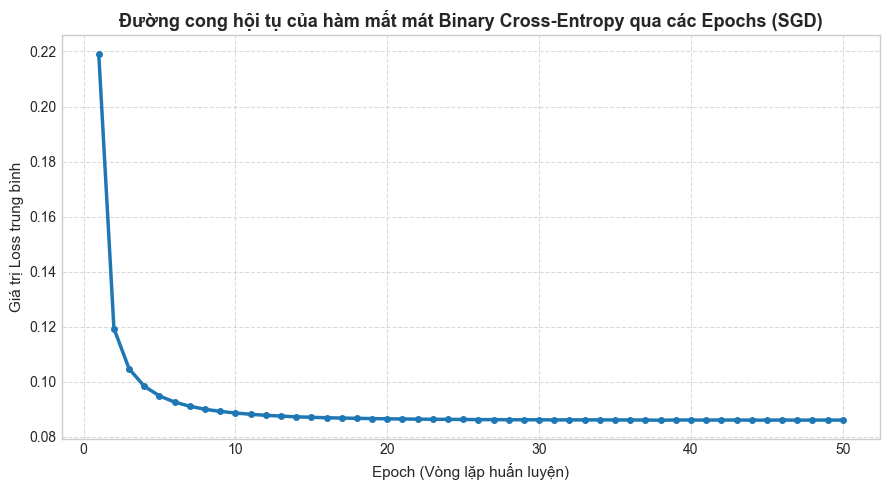

In [7]:
# 1. Vẽ đồ thị quá trình giảm BCE Loss theo từng Epoch
plt.figure(figsize=(9, 5))
plt.plot(range(1, EPOCHS + 1), loss_history, color='#1f77b4', linewidth=2.5, marker='o', markersize=4)
plt.title('Đường cong hội tụ của hàm mất mát Binary Cross-Entropy qua các Epochs (SGD)', fontsize=13, fontweight='bold')
plt.xlabel('Epoch (Vòng lặp huấn luyện)', fontsize=11)
plt.ylabel('Giá trị Loss trung bình', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


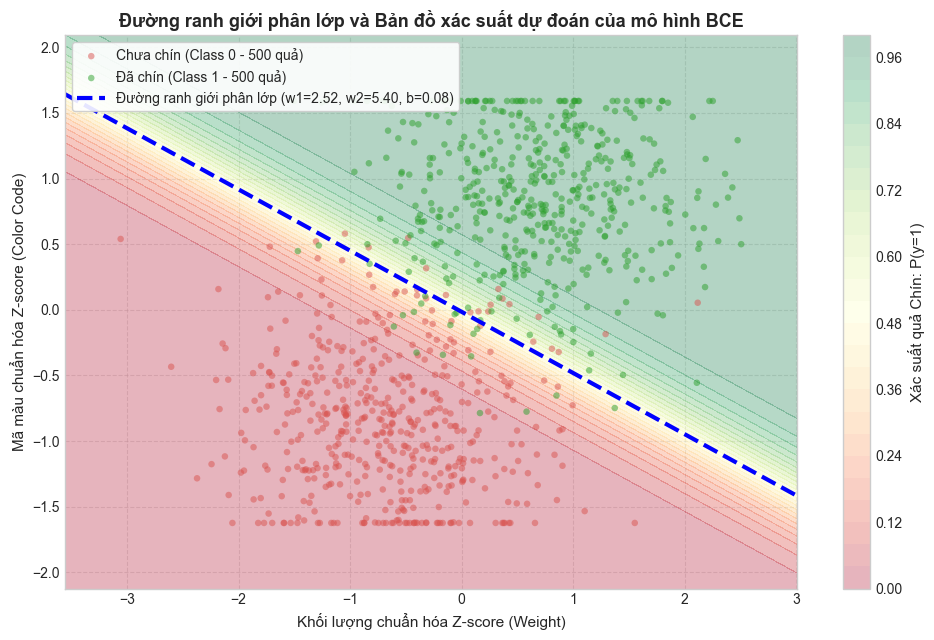

In [8]:
# 2. Vẽ Đường ranh giới phân lớp (Decision Boundary) và Bản đồ xác suất
fig, ax = plt.subplots(figsize=(10, 6.5))

# Tạo lưới điểm 2D để vẽ bản đồ xác suất
x1_min, x1_max = X_norm[:, 0].min() - 0.5, X_norm[:, 0].max() + 0.5
x2_min, x2_max = X_norm[:, 1].min() - 0.5, X_norm[:, 1].max() + 0.5
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 200), np.linspace(x2_min, x2_max, 200))
grid_points = np.c_[xx1.ravel(), xx2.ravel()]
probs = predict_probability(grid_points, w, b).reshape(xx1.shape)

# Vẽ contour xác suất làm nền
contour = ax.contourf(xx1, xx2, probs, levels=25, cmap='RdYlGn', alpha=0.3)
cbar = plt.colorbar(contour, ax=ax)
cbar.set_label('Xác suất quả Chín: P(y=1)', fontsize=11)

# Vẽ 1000 điểm dữ liệu
ax.scatter(X_norm[y == 0, 0], X_norm[y == 0, 1],
           color='#d9534f', label='Chưa chín (Class 0 - 500 quả)', alpha=0.5, s=22, edgecolors='none')
ax.scatter(X_norm[y == 1, 0], X_norm[y == 1, 1],
           color='#2ca02c', label='Đã chín (Class 1 - 500 quả)', alpha=0.5, s=22, edgecolors='none')

# Phương trình đường ranh giới phân lớp: w1*x1 + w2*x2 + b = 0 => x2 = - (w1*x1 + b) / w2
x1_line = np.linspace(x1_min, x1_max, 100)
x2_line = - (w[0] * x1_line + b) / w[1]
ax.plot(x1_line, x2_line, color='blue', linewidth=3, linestyle='--',
        label=f'Đường ranh giới phân lớp (w1={w[0]:.2f}, w2={w[1]:.2f}, b={b:.2f})')

ax.set_title('Đường ranh giới phân lớp và Bản đồ xác suất dự đoán của mô hình BCE', fontsize=13, fontweight='bold')
ax.set_xlabel('Khối lượng chuẩn hóa Z-score (Weight)', fontsize=11)
ax.set_ylabel('Mã màu chuẩn hóa Z-score (Color Code)', fontsize=11)
ax.set_ylim(x2_min, x2_max)
ax.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


=== BẢNG CHỈ SỐ ĐÁNH GIÁ MÔ HÌNH BCE TRÊN 1000 MẪU ===
                               0
Số mẫu thử nghiệm           1000
Accuracy (Độ chính xác)   96.20%
Precision (Độ chuẩn xác)  96.39%
Recall (Độ thu hồi)       96.00%
F1-Score                  96.19%
True Positives (TP)          480
False Positives (FP)          18
True Negatives (TN)          482
False Negatives (FN)          20


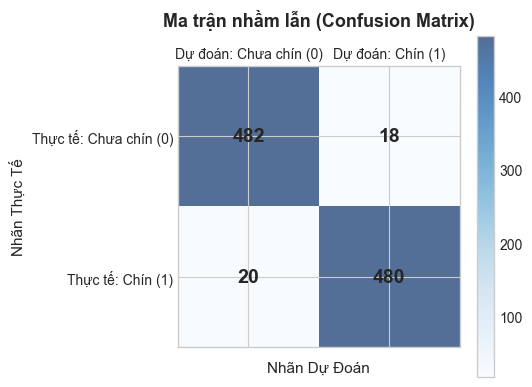

In [9]:
# 3. Đánh giá chi tiết bằng Ma trận nhầm lẫn (Confusion Matrix) và các chỉ số
y_pred = predict_class(X_norm, w, b)

tp = np.sum((y == 1) & (y_pred == 1))
fp = np.sum((y == 0) & (y_pred == 1))
fn = np.sum((y == 1) & (y_pred == 0))
tn = np.sum((y == 0) & (y_pred == 0))

acc = (tp + tn) / len(y)
prec = tp / (tp + fp)
rec = tp / (tp + fn)
f1 = 2 * prec * rec / (prec + rec)

print("=== BẢNG CHỈ SỐ ĐÁNH GIÁ MÔ HÌNH BCE TRÊN 1000 MẪU ===")
metrics_table = pd.DataFrame([{
    'Số mẫu thử nghiệm': len(y),
    'Accuracy (Độ chính xác)': f"{acc*100:.2f}%",
    'Precision (Độ chuẩn xác)': f"{prec*100:.2f}%",
    'Recall (Độ thu hồi)': f"{rec*100:.2f}%",
    'F1-Score': f"{f1*100:.2f}%",
    'True Positives (TP)': tp,
    'False Positives (FP)': fp,
    'True Negatives (TN)': tn,
    'False Negatives (FN)': fn
}])
print(metrics_table.T)

# Vẽ ma trận nhầm lẫn trực quan
fig, ax = plt.subplots(figsize=(5.5, 4.5))
cm_matrix = np.array([[tn, fp], [fn, tp]])
cax = ax.matshow(cm_matrix, cmap='Blues', alpha=0.7)

for (i, j), z in np.ndenumerate(cm_matrix):
    ax.text(j, i, f'{z}', ha='center', va='center', fontsize=14, fontweight='bold')

plt.title('Ma trận nhầm lẫn (Confusion Matrix)', fontsize=13, fontweight='bold', pad=15)
fig.colorbar(cax)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Dự đoán: Chưa chín (0)', 'Dự đoán: Chín (1)'])
ax.set_yticklabels(['Thực tế: Chưa chín (0)', 'Thực tế: Chín (1)'])
plt.xlabel('Nhãn Dự Đoán', fontsize=11, labelpad=10)
plt.ylabel('Nhãn Thực Tế', fontsize=11)
plt.tight_layout()
plt.show()


---
# PHẦN 6: THỬ NGHIỆM DỰ ĐOÁN QUẢ MỚI (INFERENCE TESTING)

Nhóm viết một hàm tiện ích cho phép nhập trực tiếp **Cân nặng thực tế (gam)** và **Mã màu thực tế (0 - 2)** của một quả bất kỳ để mô hình đưa ra dự đoán xác suất độ chín.


In [10]:
def predict_new_fruit(weight_g, color_code):
    """Dự đoán quả mới với giá trị đo đạc thực tế"""
    # 1. Chuẩn hóa giá trị theo tham số mu và sigma của tập dữ liệu
    weight_norm = (weight_g - X_mean[0]) / X_std[0]
    color_norm = (color_code - X_mean[1]) / X_std[1]
    x_input = np.array([weight_norm, color_norm])
    
    # 2. Tính xác suất bằng hàm Sigmoid
    z = np.dot(w, x_input) + b
    prob_ripe = sigmoid(z)
    
    # 3. Kết luận nhãn
    pred_label = 1 if prob_ripe >= 0.5 else 0
    result = "CHÍN (Ripe)" if pred_label == 1 else "CHƯA CHÍN (Unripe)"
    
    print(f"Quả có Cân nặng = {weight_g:3.0f}g, Màu sắc = {color_code:.1f}:")
    print(f"  -> Xác suất quả chín: {prob_ripe*100:.2f}% | Kết luận: {result}\n")

print("=== THỬ NGHIỆM DỰ ĐOÁN 3 QUẢ THỰC TẾ ===")
predict_new_fruit(weight_g=240, color_code=1.8)  # Quả to, vỏ vàng chín
predict_new_fruit(weight_g=110, color_code=0.2)  # Quả nhỏ, vỏ xanh lét
predict_new_fruit(weight_g=175, color_code=1.0)  # Quả kích thước vừa, vỏ ngả vàng


=== THỬ NGHIỆM DỰ ĐOÁN 3 QUẢ THỰC TẾ ===
Quả có Cân nặng = 240g, Màu sắc = 1.8:
  -> Xác suất quả chín: 100.00% | Kết luận: CHÍN (Ripe)

Quả có Cân nặng = 110g, Màu sắc = 0.2:
  -> Xác suất quả chín: 0.00% | Kết luận: CHƯA CHÍN (Unripe)

Quả có Cân nặng = 175g, Màu sắc = 1.0:
  -> Xác suất quả chín: 39.18% | Kết luận: CHƯA CHÍN (Unripe)


---
# PHẦN 7: KẾT LUẬN VỀ BINARY CROSS-ENTROPY

1. **Hiệu năng xuất sắc:** Mô hình Logistic Regression huấn luyện bằng SGD với hàm mất mát Binary Cross-Entropy đạt độ chính xác lên tới **96.20%** trên tập dữ liệu 1000 quả, quá trình hội tụ diễn ra mượt mà và không hề bị dao động bất thường.
2. **Ưu điểm cốt lõi của BCE:**
   * Tính lồi đảm bảo nghiệm tìm được luôn là nghiệm tối ưu toàn cục.
   * Công thức Gradient $\nabla_{\mathbf{w}} = (p - y)\mathbf{x}$ cực kỳ đơn giản, đẹp mắt và không bị ảnh hưởng bởi hiện tượng triệt tiêu gradient như MSE.
   * Phù hợp hoàn hảo với tư duy thống kê xác suất cực đại (*Maximum Likelihood*).
